In [1]:
%load_ext autoreload
%autoreload 2
#%env JAX_PLATFORM_NAME=cpu
#%env JAX_ENABLE_X64=True
%matplotlib inline
#%matplotlib tk
import numpy as np
import numpy.linalg as lg
#from sklearn.model_selection import train_test_split
import jax
from util_pred import cov_mat
from morphomatics.manifold import Sphere, PowerManifold
from morphomatics.stats import ExponentialBarycenter
from timeseries.verification_metrics import errfun
from timeseries.stats import load_sph, sph_correlated_trjs
from timeseries.main import pred
from timeseries.model import (AVGEnsemble, VelocityEnsemble, Reg, RidgeReg)
from util import visSphere
from util_pred import fit_poly_dc
# Set random seed for reproducibility (optional)
#np.random.seed(42)

# Global constants and parameters
M = Sphere()
dist = jax.jit(M.metric.dist)
err = errfun(M.metric.dist)
avg = AVGEnsemble(alpha=0.5)
def read_data(load, mean_curve):
    if load:
        B, Y = load_sph(mean_curve)
    else:
         # Reda Data: Random trajectories
        noise_std = 0.05
        n_subj, n_points = 30, 45
        lon_max, lat_max = .75*np.pi, np.pi/20  # 4.5
        Y = sph_correlated_trjs(lon_max, lat_max, n_trj=n_subj, n_points=n_points, noise_std=noise_std,mean_curve=mean_curve)  # Gauss noise
        #Y = rand_trjs(n_mat=n_subj, n_points=n_points)
        B, _ = fit_poly_dc(M, Y, deg=deg)
        #save_sph(B, Y, mean_curve)
        #Y = Y_fit
    return Y, B

In [2]:
# Test setting
mean_curve = 'Poly'  # 'Geo', 'Poly', 'Else'
Y, B = read_data(load=True, mean_curve=mean_curve)
n_train = 20
Y_train, B_train, Y_test = Y[:n_train], B[:n_train], Y[n_train:]
n_cp = np.shape(B_train[0])[0]
deg = n_cp - 1
P = PowerManifold(M, n_cp)
n_test = len(Y_test)
Ytest = Y_test[5:] # Y_test[0:2]
Ytest = [y[:35] for y in Ytest]
AV_ensemble = VelocityEnsemble(alpha=0.5)
pred_args = {
    'n_learn': n_cp,
    'n_pred': 1,
    'iterative': True
}

In [3]:
# Regression
model = Reg(M, lag=True, degree=deg)
Y_pred_ols, metrics_ols = pred(Ytest, model, **pred_args, ensemble_strategy= None)
Y_pred_ols_avg, metrics_ols_avg = pred(Ytest, model, **pred_args, ensemble_strategy= avg)

MAE: 0.0351 +/- 0.0167
MAE: 0.0258 +/- 0.0157


In [12]:
# Ridge regression
# Covariance matrix and mean
Ex = ExponentialBarycenter()
mean_b_train = Ex.compute(P, B_train, max_iter=30)
cov_b_train = cov_mat(P.metric.log, B_train, mean_b_train) #+ 1e-6*np.eye(n_cp*dim)
#w = jax.vmap(jax.jit(P.metric.log), (None, 0))(mean_b_train, B_train)
#w_vec = w.reshape(n_train, -1)
#cov_b_train, shrinkage = ledoit_wolf(w_vec)
# Analyze correlation
dists_to_mean = [P.metric.dist(mean_b_train, b) for b in B_train]
eigenvalues = np.sort(lg.eigvalsh(cov_b_train))[::-1]
print(f"\nDistance to mean: {np.mean(dists_to_mean):.4f} ± {np.std(dists_to_mean):.4f}")
print(f"Eigenvalues: {eigenvalues}")
print(f"Variance explained by PC2: {eigenvalues[:2].sum()/eigenvalues.sum():.1%}")
#cov_b_train = 1e+6*cov_b_train

# mu=1e-2[1e-4, 1e-2, 1, 5, 10, 20, 40] min at mu = 5*1e-2 equal 0.0301
mu = .02*1e-1
mu = 11*1e-3
model = RidgeReg(M, mean_b_train, cov_b_train, mu, lag=True, degree=deg)
#Y_pred_new, metrics = pred(Ytest, model, **pred_args, ensemble_strategy= None)
Y_pred_ridge, metrics_ridge = pred(Ytest, model, **pred_args, ensemble_strategy= avg)


Distance to mean: 0.1192 ± 0.0249
Eigenvalues: [ 4.35406227e-03  2.91872864e-03  2.40091721e-03  1.79418187e-03
  1.32912561e-03  8.45477504e-04  4.42763292e-04  3.02411244e-04
  2.37525835e-04  1.02138952e-04  7.14917927e-05  2.71805421e-05
  2.34069943e-19  1.35920611e-19  6.12925670e-20 -6.21702751e-21
 -7.15844711e-20 -3.45684230e-19]
Variance explained by PC2: 49.1%
MAE: 0.0241 +/- 0.0136


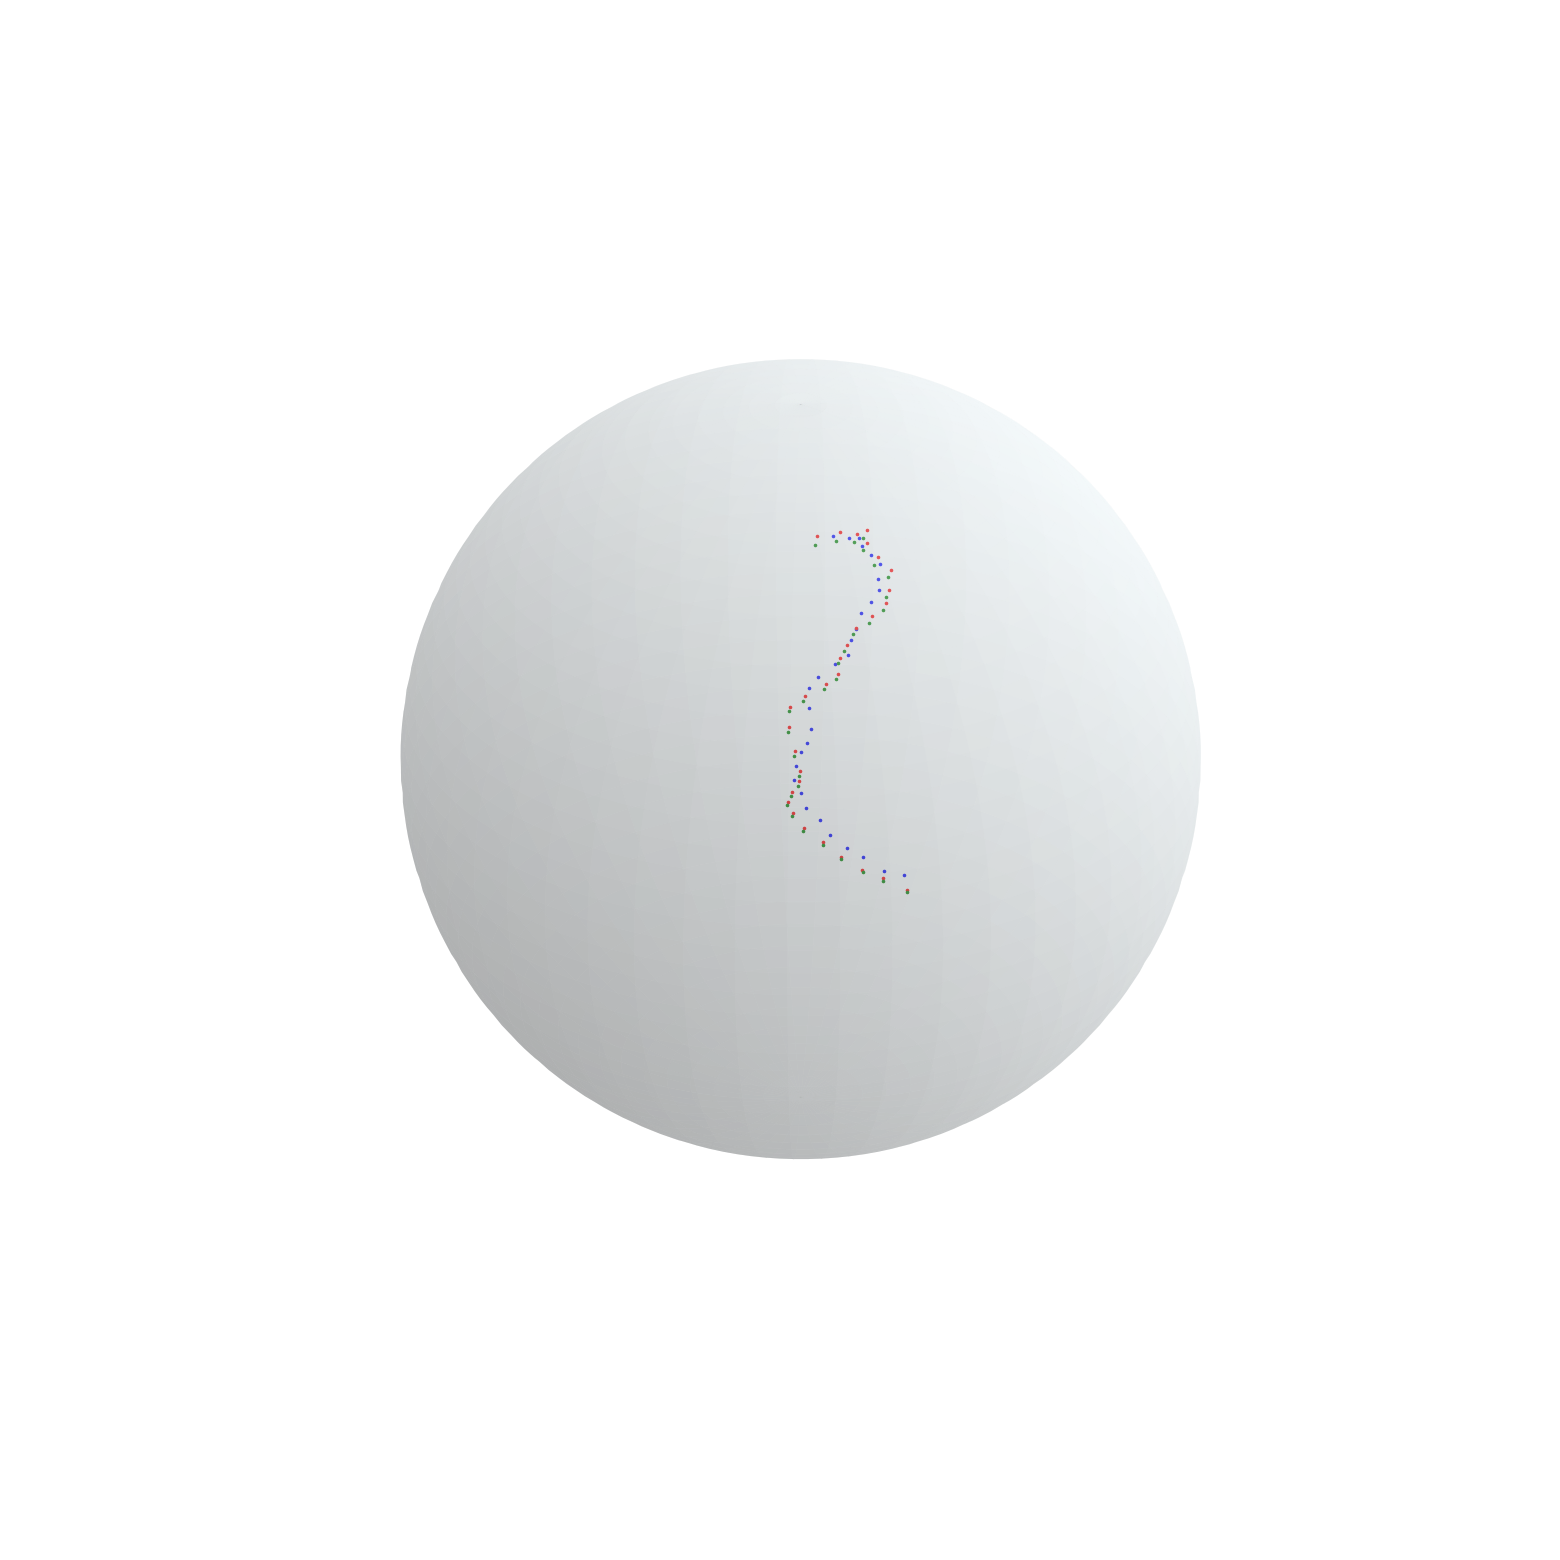

In [9]:
k = 0
visSphere([Ytest[k][-30:], Y_pred_ols[k][-30:], Y_pred_ridge[k][-30:]], ['b', 'g', 'r'])

In [10]:
path = '../datasets/visPoly.npz'
ytest, yols, yridge = Ytest[k], [Y_pred_ols[k]], [Y_pred_ridge[k]]
np.savez(path, ytest=np.array(ytest, dtype=object), yols=np.array(yols, dtype=object), yridge=np.array(yridge, dtype=object))